# Quantitative Evaluation of Explainable Deep Reinforcement Learning (Continuous DQN) in Dairy Supply Chain Optimization


## Setup Device


In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Ignore Warning


In [2]:
import warnings

warnings.filterwarnings("ignore")

## Creating Directory


In [3]:
from pathlib import Path

# Define your directory path
dir_path = Path("./plots")

# Create directory safely
dir_path.mkdir(parents=True, exist_ok=True)

# Define your directory path
dir_path = Path("./results")

# Create directory safely
dir_path.mkdir(parents=True, exist_ok=True)

## Research-Grade Visualization


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (12, 7),
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif"],
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "lines.linewidth": 2.0,
        "grid.alpha": 0.3,
        "grid.linestyle": "--",
        "axes.linewidth": 1.2,
    }
)
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

## Load Data


In [5]:
import os
import kagglehub
import pandas as pd

print("Loading data...")
path = kagglehub.dataset_download("debarghamitraroy/dairy-production-dataset")
data_path = os.path.join(path, "train.csv")
df = pd.read_csv(data_path)
print("Data loading was successful...")

Loading data...
Data loading was successful...


In [6]:
num_rows, num_cols = df.shape
print(f"Rows: {num_rows}")
print(f"Columns: {num_cols}")

Rows: 122983
Columns: 24


## Environment Formulation & Offline Data Engineering


### Temporal Feature Engineering


In [7]:
print("Processing temporal features...")

# Convert date columns to datetime objects dates are in DD-MM-YYYY format
date_cols = ["Date", "Production Date", "Expiration Date"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format="%d-%m-%Y", errors="coerce")

# Calculate 'Days to Expiration'
# This is the exact number of days left from the current transaction 'Date' until the product spoils.
df["Days_to_Expiration"] = (df["Expiration Date"] - df["Date"]).dt.days

# Drop rows where expiration is negative (already spoiled before the record date) or where dates are missing due to parsing errors.
df = df[df["Days_to_Expiration"] >= 0].copy()

# Calculate Age of product since production
df["Product_Age_Days"] = (df["Date"] - df["Production Date"]).dt.days

print("Processing temporal features was successful...")

Processing temporal features...
Processing temporal features was successful...


### Age-Structured Inventory Matrix (FIFO)


In [8]:
print("Building FIFO age-structured matrices...")
# In Deep RL, the agent needs a fixed-size vector to understand inventory age.
# We will create a vector up to 'MAX_SHELF_LIFE' (e.g., 30 days).
# Bins: [Expiring in 0-2 days, 3-5 days, ..., 20+ days]

MAX_SHELF_LIFE = 30  # Cap for the maximum days we track individually

# Pivot the data to create a state vector for each Product ID on each Date
# We group by Date and Product ID, and sum the Quantity in Stock for each expiration day.
fifo_matrix = df.pivot_table(
    index=["Date", "Product ID"],
    columns="Days_to_Expiration",
    values="Quantity in Stock (liters/kg)",
    aggfunc="sum",
    fill_value=0,
)

# Truncate and group columns beyond MAX_SHELF_LIFE to prevent infinite state space expansion
cols_to_keep = [col for col in fifo_matrix.columns if col <= MAX_SHELF_LIFE]
cols_to_group = [col for col in fifo_matrix.columns if col > MAX_SHELF_LIFE]

if cols_to_group:
    fifo_matrix[f">{MAX_SHELF_LIFE}_Days"] = fifo_matrix[cols_to_group].sum(axis=1)
    fifo_matrix = fifo_matrix.drop(columns=cols_to_group)

# Rename columns for clarity in the RL State Vector
fifo_matrix.columns = [
    f"Stock_Expiring_in_{int(col)}_Days" if isinstance(col, (int, float)) else col
    for col in fifo_matrix.columns
]

print(f"Created FIFO matrix with shape: {fifo_matrix.shape}")

Building FIFO age-structured matrices...
Created FIFO matrix with shape: (56546, 32)


### Multicollinearity Detection


In [9]:
import numpy as np

print("Analyzing Multicollinearity for XAI ROAR/PI evaluation...")

# Select only numerical columns for correlation
numerical_df = df.select_dtypes(include=[np.number])

# Calculate the Pearson correlation matrix
corr_matrix = numerical_df.corr().abs()

# Create a mask to ignore the diagonal and the lower triangle (to avoid duplicate pairs)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Set a threshold for identifying highly collinear features
COLLINEAR_THRESHOLD = 0.85

# Find index pairs with correlation above the threshold
collinear_pairs = [
    (upper_tri.columns[i], upper_tri.columns[j], upper_tri.iloc[i, j])
    for i in range(len(upper_tri.columns))
    for j in range(i + 1, len(upper_tri.columns))
    if upper_tri.iloc[i, j] > COLLINEAR_THRESHOLD
]

print(f"\nHighly Collinear Feature Pairs (Threshold > {COLLINEAR_THRESHOLD}):")

for feat1, feat2, corr_val in collinear_pairs:
    print(f"[{corr_val:.3f}] {feat1} <--> {feat2}")

Analyzing Multicollinearity for XAI ROAR/PI evaluation...

Highly Collinear Feature Pairs (Threshold > 0.85):
[0.988] Price per Unit <--> Price per Unit (sold)


## State & Action Formulation


### Create the RL Environment DataFrame


In [10]:
rl_df = df.merge(fifo_matrix, on=["Date", "Product ID"], how="left")
rl_df.fillna(0, inplace=True)
print("Shape:", rl_df.shape)

Shape: (60035, 58)


### Encode Categorical Variables


In [11]:
import joblib
from pathlib import Path
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Neural networks require numeric inputs. We encode string categories into integers.
print("Encoding categorical variables...")
categorical_cols = [
    "Location",
    "Farm Size",
    "Product Name",
    "Brand",
    "Storage Condition",
    "Sales Channel",
]
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    rl_df[col] = le.fit_transform(rl_df[col].astype(str))
    encoders[col] = le

Encoding categorical variables...


### Define State (S) Features


In [12]:
# The state represents the "observation" the agent sees before making a decision.
state_cols = [
    "Location",
    "Total Land Area (acres)",
    "Number of Cows",
    "Farm Size",
    "Product ID",
    "Product Name",
    "Brand",
    "Shelf Life (days)",
    "Storage Condition",
    "Quantity in Stock (liters/kg)",
    "Minimum Stock Threshold (liters/kg)",
    "Price per Unit",  # Base cost (Environmental constraint)
    "Days_to_Expiration",
    "Product_Age_Days",
] + list(fifo_matrix.columns)  # Append the dynamic age-structured inventory

print(f"State vector comprises {len(state_cols)} dimensions.")

State vector comprises 46 dimensions.


### Define Action (A) Features


In [13]:
# As modeled in the literature, we use a continuous action space controlling dynamic pricing and inventory simultaneously.
action_cols = ["Price per Unit (sold)", "Reorder Quantity (liters/kg)"]
print(f"Action vector comprises {len(action_cols)} dimensions.")

Action vector comprises 2 dimensions.


### Extract and Scale the Matrices


In [14]:
# Deep RL algorithms require standardized inputs (Mean=0, Std=1) to prevent exploding gradients and ensure stable convergence.
print("\nScaling State and Action matrices...")
scaler_S = StandardScaler()
scaler_A = StandardScaler()

# Extract raw matrices
S_raw = rl_df[state_cols].values
A_raw = rl_df[action_cols].values

# Fit and transform
S_matrix = scaler_S.fit_transform(S_raw)
A_matrix = scaler_A.fit_transform(A_raw)

print(f"-> State Space (S) shape: {S_matrix.shape}")
print(f"-> Action Space (A) shape: {A_matrix.shape}")

# Store the final dataframe for the Reward engineering step
rl_df_final = rl_df.copy()


Scaling State and Action matrices...
-> State Space (S) shape: (60035, 46)
-> Action Space (A) shape: (60035, 2)


## Reward Engineering & Shaping


### Base Financial Sub-Rewards (Multi-Objective Decomposition)


In [15]:
df_reward = rl_df_final.copy()
print("Calculating financial sub-rewards...")

# A. Gross Profit: Revenue minus the baseline cost of the goods sold
rl_df_final["Gross_Profit"] = rl_df_final["Approx. Total Revenue(INR)"] - (
    rl_df_final["Quantity Sold (liters/kg)"] * rl_df_final["Price per Unit"]
)

# B. Waste Penalty
waste_col = (
    "Stock_Expiring_in_0_Days"
    if "Stock_Expiring_in_0_Days" in rl_df_final.columns
    else "Stock_Expiring_in_1_Days"
)
rl_df_final["Waste_Penalty"] = (
    rl_df_final[waste_col] * rl_df_final["Price per Unit"] * 1.5
)

# C. Holding Cost
rl_df_final["Holding_Cost"] = (
    rl_df_final["Quantity in Stock (liters/kg)"] * rl_df_final["Price per Unit"] * 0.05
)

# D. Stockout Penalty
rl_df_final["Stockout_Penalty"] = np.where(
    rl_df_final["Quantity in Stock (liters/kg)"]
    < rl_df_final["Minimum Stock Threshold (liters/kg)"],
    (
        rl_df_final["Minimum Stock Threshold (liters/kg)"]
        - rl_df_final["Quantity in Stock (liters/kg)"]
    )
    * rl_df_final["Price per Unit"]
    * 2.0,
    0,
)

Calculating financial sub-rewards...


### Aggregating the Raw Reward


In [16]:
print("Aggregating Raw Reward...")
rl_df_final["Raw_Reward"] = (
    rl_df_final["Gross_Profit"]
    - rl_df_final["Waste_Penalty"]
    - rl_df_final["Holding_Cost"]
    - rl_df_final["Stockout_Penalty"]
)
print("Aggregating Raw Reward successfully...")

Aggregating Raw Reward...
Aggregating Raw Reward successfully...


### Preference As Reward (PAR) Bounding


In [17]:
print("Applying Preference As Reward (PAR) bounding...")

r_median = rl_df_final["Raw_Reward"].median()
r_std = rl_df_final["Raw_Reward"].std()


def par_transform(r, ref, std, k=2.0):
    return 2 / (1 + np.exp(-k * (r - ref) / std)) - 1


rl_df_final["Bounded_Reward_PAR"] = par_transform(
    rl_df_final["Raw_Reward"], r_median, r_std
)

Applying Preference As Reward (PAR) bounding...


### Extract Final MDP Arrays for Training


In [18]:
R_matrix = rl_df_final["Bounded_Reward_PAR"].values

print("\nReward Summary Statistics:")
print(rl_df_final[["Raw_Reward", "Bounded_Reward_PAR"]].describe())
print(f"\n-> Reward Space (R) shape: {R_matrix.shape}")


Reward Summary Statistics:
          Raw_Reward  Bounded_Reward_PAR
count   60035.000000        60035.000000
mean    -2024.795992           -0.048919
std      7576.005953            0.492767
min   -149276.123916           -1.000000
25%     -4334.923495           -0.390078
50%     -1214.426635            0.000000
75%       716.080589            0.249443
max     60077.369805            1.000000

-> Reward Space (R) shape: (60035,)


## Deep RL Surrogate Training (Offline Continuous DQN)


### Replay Buffer Initialization & Transition Engineering


#### Temporal Transition Engineering (S, A, R, S')


In [19]:
print("Extracting MDP Transitions (S_t, A_t, R_t, S_t+1)...")

# Sort chronologically to preserve episode trajectories
rl_df_final = rl_df_final.sort_values(
    by=["Location", "Product ID", "Date"]
).reset_index(drop=True)

# Re-extract the matrices temporally
S_raw = rl_df_final[state_cols].values
A_matrix = scaler_A.transform(rl_df_final[action_cols].values)
R_matrix = rl_df_final["Bounded_Reward_PAR"].values
S_matrix = scaler_S.transform(S_raw)

# Calculate Next State (S_t+1)
S_next_matrix = np.roll(S_matrix, shift=-1, axis=0)

# Identify Terminal States (Episode boundaries)
is_terminal = (
    (rl_df_final["Product ID"] != rl_df_final["Product ID"].shift(-1))
    | (rl_df_final["Location"] != rl_df_final["Location"].shift(-1))
).values.copy()

is_terminal[-1] = True

print(f"Extracted {len(S_matrix)} total transitions.")
print(f"Identified {is_terminal.sum()} terminal states (Episode boundaries).")

Extracting MDP Transitions (S_t, A_t, R_t, S_t+1)...
Extracted 60035 total transitions.
Identified 54196 terminal states (Episode boundaries).


### Continuous DQN Architecture


#### Continuous Actor-Critic Network


In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal


class ContinuousDQNAgent(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(ContinuousDQNAgent, self).__init__()

        # Shared Feature Encoder (Optional baseline representation)
        self.shared_layers = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
        )

        # Actor Network: Continuous Gaussian Policy
        self.actor_mean = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, action_dim)
        )
        # Learnable standard deviation for continuous actions
        self.actor_log_std = nn.Parameter(torch.zeros(1, action_dim))

        # Critic Network: V(s) Evaluates the state baseline
        self.critic = nn.Sequential(nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1))

    def forward(self, state):
        shared_features = self.shared_layers(state)

        # Policy Mean Output
        mean = self.actor_mean(shared_features)

        # Expand log_std to match the batch size
        std = torch.exp(self.actor_log_std).expand_as(mean)

        # State Value V(s)
        value = self.critic(shared_features)

        return mean, std, value

    def evaluate_actions(self, state, action):
        """Used during mini-batch optimization to compute policy log ratios and entropy."""
        mean, std, value = self.forward(state)

        dist = Normal(mean, std)
        log_prob = dist.log_prob(action).sum(dim=-1, keepdim=True)
        entropy = dist.entropy().sum(dim=-1, keepdim=True)

        return log_prob, value, entropy, mean

### Initialization & Architecture Validation


In [21]:
print("Instantiating Continuous DQN Architecture...")

STATE_DIM = 46
ACTION_DIM = 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the Continuous DQN Agent
dqn_agent = ContinuousDQNAgent(state_dim=STATE_DIM, action_dim=ACTION_DIM).to(device)

print(f"Model successfully mapped to device: {device}")

# Sanity Check Forward Pass
print("\nTesting Forward Pass...")
dummy_states = torch.randn(64, STATE_DIM).to(device)
mean, std, value = dqn_agent(dummy_states)

print(f"-> Input State Shape: {dummy_states.shape}")
print(f"-> Output Action Mean Shape: {mean.shape}")
print(f"-> Output Action Std Shape: {std.shape}")
print(f"-> Output Value V(s) Shape: {value.shape}")
print("Testing Forward Pass successfully...")

Instantiating Continuous DQN Architecture...
Model successfully mapped to device: cuda

Testing Forward Pass...
-> Input State Shape: torch.Size([64, 46])
-> Output Action Mean Shape: torch.Size([64, 2])
-> Output Action Std Shape: torch.Size([64, 2])
-> Output Value V(s) Shape: torch.Size([64, 1])
Testing Forward Pass successfully...


### Offline Policy Optimization (Clipped Continuous DQN Loop)


#### Training Hyperparameters


In [22]:
from torch.utils.data import TensorDataset, DataLoader
import time

# Hyperparameters for Continuous DQN (PPO variant)
EPOCHS = 15  # Outer loop over the offline data
PPO_EPOCHS = 4  # Mini-batch optimization epochs per outer epoch
BATCH_SIZE = 2048
GAMMA = 0.99  # Discount factor
GAE_LAMBDA = 0.95  # Generalized Advantage Estimation lambda
CLIP_EPSILON = 0.2  # Policy clipping bound
ENTROPY_COEF = 0.01  # Entropy regularization bonus
VALUE_COEF = 0.5  # Value loss weight
LR = 3e-4

optimizer = optim.Adam(dqn_agent.parameters(), lr=LR)

# Prepare full dataset tensors
S_tensor = torch.tensor(S_matrix, dtype=torch.float32).to(device)
A_tensor = torch.tensor(A_matrix, dtype=torch.float32).to(device)
R_tensor = torch.tensor(R_matrix, dtype=torch.float32).unsqueeze(1).to(device)
S_next_tensor = torch.tensor(S_next_matrix, dtype=torch.float32).to(device)
D_tensor = torch.tensor(is_terminal, dtype=torch.float32).unsqueeze(1).to(device)

training_history = {
    "policy_loss": [],
    "value_loss": [],
    "entropy": [],
    "explained_variance": [],
}

### Main Offline Continuous DQN Training Loop


In [23]:
start_time = time.time()
dqn_agent.train()

print(f"Starting Offline Continuous DQN Training: {EPOCHS} Epochs")

for epoch in range(EPOCHS):
    # 1. Evaluate historical offline trajectories using the current network to calculate Advantages (GAE)
    with torch.no_grad():
        _, _, values = dqn_agent(S_tensor)
        _, _, next_values = dqn_agent(S_next_tensor)

        advantages = torch.zeros_like(R_tensor).to(device)
        last_gae_lambda = 0

        # Compute GAE backwards through the trajectories respecting episode boundaries
        for t in reversed(range(len(R_tensor))):
            next_non_terminal = 1.0 - D_tensor[t]
            delta = R_tensor[t] + GAMMA * next_values[t] * next_non_terminal - values[t]
            advantages[t] = last_gae_lambda = (
                delta + GAMMA * GAE_LAMBDA * next_non_terminal * last_gae_lambda
            )

        returns = advantages + values

        # Treat the agent's current output as the behavior policy for computing ratios
        old_log_probs, _, _, _ = dqn_agent.evaluate_actions(S_tensor, A_tensor)

    # 2. Advantage Normalization for training stability
    adv_mean = advantages.mean()
    adv_std = advantages.std() + 1e-8
    normalized_advantages = (advantages - adv_mean) / adv_std

    # Prepare mini-batches
    dataset = TensorDataset(
        S_tensor, A_tensor, old_log_probs, returns, normalized_advantages
    )
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

    epoch_p_loss = 0.0
    epoch_v_loss = 0.0
    epoch_ent = 0.0

    # 3. Mini-Batch Optimization Phase
    for ppo_epoch in range(PPO_EPOCHS):
        for b_states, b_actions, b_old_log_probs, b_returns, b_advantages in dataloader:
            # Evaluate current policy
            new_log_probs, b_values, entropy, _ = dqn_agent.evaluate_actions(
                b_states, b_actions
            )

            # Policy Ratio (r_t)
            ratio = torch.exp(new_log_probs - b_old_log_probs)

            # Clipped Surrogate Loss
            surr1 = ratio * b_advantages
            surr2 = (
                torch.clamp(ratio, 1.0 - CLIP_EPSILON, 1.0 + CLIP_EPSILON)
                * b_advantages
            )
            policy_loss = -torch.min(surr1, surr2).mean()

            # Value Loss (MSE)
            value_loss = nn.MSELoss()(b_values, b_returns)

            # Entropy Bonus (Encourages exploration / mitigates premature convergence)
            entropy_loss = entropy.mean()

            # Combined Objective
            total_loss = (
                policy_loss + VALUE_COEF * value_loss - ENTROPY_COEF * entropy_loss
            )

            # Optimizer Step
            optimizer.zero_grad()
            total_loss.backward()
            nn.utils.clip_grad_norm_(dqn_agent.parameters(), 0.5)  # Gradient clipping
            optimizer.step()

            epoch_p_loss += policy_loss.item()
            epoch_v_loss += value_loss.item()
            epoch_ent += entropy_loss.item()

    # Calculate Epoch Metrics
    num_batches = len(dataloader) * PPO_EPOCHS
    avg_p_loss = epoch_p_loss / num_batches
    avg_v_loss = epoch_v_loss / num_batches
    avg_ent = epoch_ent / num_batches

    # Explained Variance (V(s) prediction quality)
    y_pred = values.cpu().numpy()
    y_true = returns.cpu().numpy()
    var_y = np.var(y_true)
    explained_var = np.nan if var_y == 0 else 1 - np.var(y_true - y_pred) / var_y

    training_history["policy_loss"].append(avg_p_loss)
    training_history["value_loss"].append(avg_v_loss)
    training_history["entropy"].append(avg_ent)
    training_history["explained_variance"].append(explained_var)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Policy Loss: {avg_p_loss:.4f} | "
        f"Value Loss: {avg_v_loss:.4f} | "
        f"Entropy: {avg_ent:.4f} | "
        f"Explained Var: {explained_var:.4f}"
    )

Starting Offline Continuous DQN Training: 15 Epochs
Epoch 01/15 | Policy Loss: -0.0287 | Value Loss: 0.4615 | Entropy: 2.8602 | Explained Var: -0.0170
Epoch 02/15 | Policy Loss: -0.0155 | Value Loss: 0.4508 | Entropy: 2.8887 | Explained Var: 0.1543
Epoch 03/15 | Policy Loss: -0.0136 | Value Loss: 0.4438 | Entropy: 2.8956 | Explained Var: 0.2744
Epoch 04/15 | Policy Loss: -0.0132 | Value Loss: 0.4516 | Entropy: 2.8860 | Explained Var: 0.3523
Epoch 05/15 | Policy Loss: -0.0125 | Value Loss: 0.4553 | Entropy: 2.8634 | Explained Var: 0.4098
Epoch 06/15 | Policy Loss: -0.0126 | Value Loss: 0.4553 | Entropy: 2.8314 | Explained Var: 0.4548
Epoch 07/15 | Policy Loss: -0.0115 | Value Loss: 0.4522 | Entropy: 2.7935 | Explained Var: 0.4863
Epoch 08/15 | Policy Loss: -0.0089 | Value Loss: 0.4459 | Entropy: 2.7517 | Explained Var: 0.5028
Epoch 09/15 | Policy Loss: -0.0093 | Value Loss: 0.4439 | Entropy: 2.7043 | Explained Var: 0.5219
Epoch 10/15 | Policy Loss: -0.0058 | Value Loss: 0.4446 | Entropy

### Continuous DQN Evaluation & Regression Metrics


In [24]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    explained_variance_score,
)

print("\nExecuting Comprehensive Prediction Profiling...")

dqn_agent.eval()
with torch.no_grad():
    A_pred_tensor, _, _ = dqn_agent(S_tensor)
    A_pred_scaled = A_pred_tensor.cpu().numpy()

# Inverse transform for true real-world scaling
A_true_real = scaler_A.inverse_transform(A_matrix)
A_pred_real = scaler_A.inverse_transform(A_pred_scaled)


def calculate_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    evs = explained_variance_score(y_true, y_pred)

    # NRMSE Accuracy: Accuracy (%) = (1 - NRMSE) * 100
    nrmse = rmse / (y_true.max() - y_true.min())
    acc = max(0, (1 - nrmse) * 100)

    print(f"\n{name} Predictions:")
    print(
        f"MAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f} | EV Score: {evs:.4f} | Accuracy: {acc:.2f}%"
    )
    return mae, rmse, r2, acc


print("-" * 60)
p_mae, p_rmse, p_r2, p_acc = calculate_metrics(
    A_true_real[:, 0], A_pred_real[:, 0], "Pricing Strategy"
)
r_mae, r_rmse, r_r2, r_acc = calculate_metrics(
    A_true_real[:, 1], A_pred_real[:, 1], "Reordering Strategy"
)
overall_drl_acc = (p_acc + r_acc) / 2
print("-" * 60)
print(f"Overall Policy Accuracy: {overall_drl_acc:.2f}%")


Executing Comprehensive Prediction Profiling...
------------------------------------------------------------

Pricing Strategy Predictions:
MAE: 20.8031 | RMSE: 27.3074 | R²: -0.0584 | EV Score: -0.0027 | Accuracy: 72.50%

Reordering Strategy Predictions:
MAE: 54.9934 | RMSE: 67.8119 | R²: -0.7124 | EV Score: -0.6845 | Accuracy: 62.31%
------------------------------------------------------------
Overall Policy Accuracy: 67.41%


#### Generate Publication-Quality Evaluation Visualizations


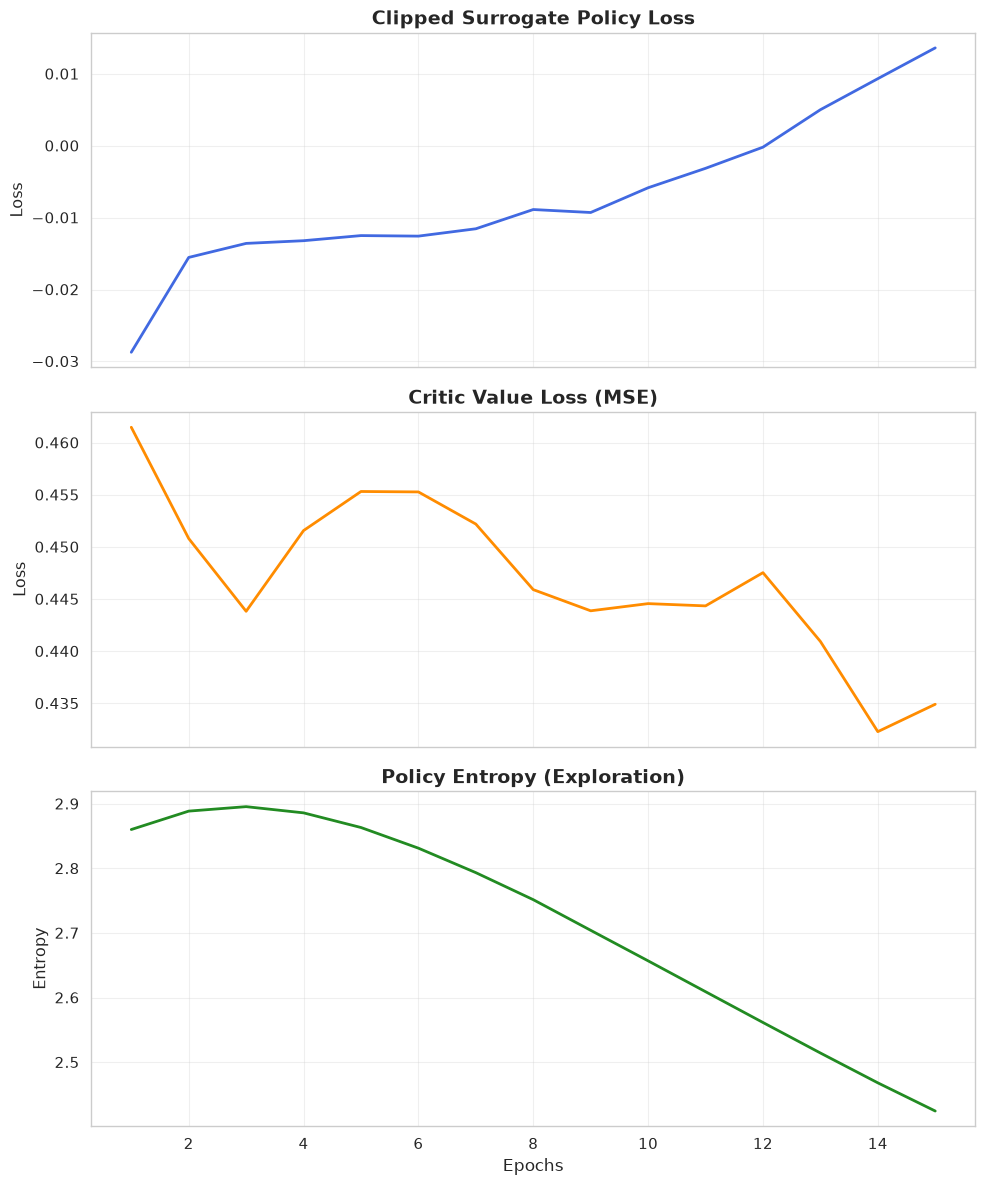

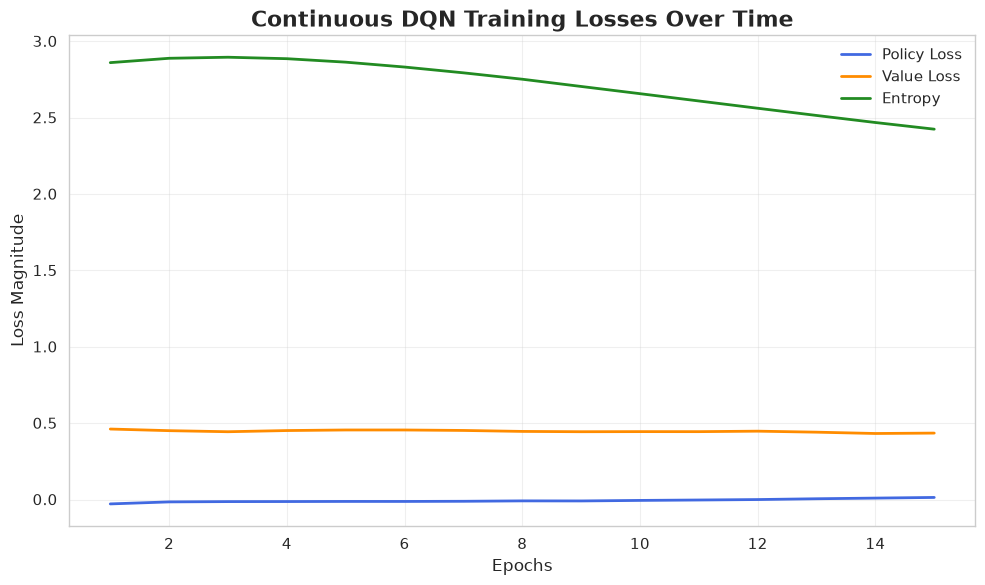

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_training_metrics(history):
    epochs = range(1, len(history["policy_loss"]) + 1)
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 12), sharex=True)

    # 1. Policy Loss Plot
    sns.lineplot(
        x=epochs, y=history["policy_loss"], ax=axes[0], color="royalblue", linewidth=2
    )
    axes[0].set_title("Clipped Surrogate Policy Loss", fontsize=14, fontweight="bold")
    axes[0].set_ylabel("Loss")

    # 2. Value Loss Plot
    sns.lineplot(
        x=epochs, y=history["value_loss"], ax=axes[1], color="darkorange", linewidth=2
    )
    axes[1].set_title("Critic Value Loss (MSE)", fontsize=14, fontweight="bold")
    axes[1].set_ylabel("Loss")

    # 3. Entropy Plot
    sns.lineplot(
        x=epochs, y=history["entropy"], ax=axes[2], color="forestgreen", linewidth=2
    )
    axes[2].set_title("Policy Entropy (Exploration)", fontsize=14, fontweight="bold")
    axes[2].set_ylabel("Entropy")
    axes[2].set_xlabel("Epochs", fontsize=12)

    plt.tight_layout()
    plt.show()

    # Combined Overlay Plot
    plt.figure(figsize=(10, 6))

    sns.lineplot(
        x=epochs,
        y=history["policy_loss"],
        label="Policy Loss",
        color="royalblue",
        linewidth=2,
    )
    sns.lineplot(
        x=epochs,
        y=history["value_loss"],
        label="Value Loss",
        color="darkorange",
        linewidth=2,
    )
    sns.lineplot(
        x=epochs,
        y=history["entropy"],
        label="Entropy",
        color="forestgreen",
        linewidth=2,
    )

    plt.title(
        "Continuous DQN Training Losses Over Time", fontsize=16, fontweight="bold"
    )
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel("Loss Magnitude", fontsize=12)

    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.savefig(
        "./plots/Continuous_DQN_Training_Losses.pdf",
        format="pdf",
        dpi=1200,
        bbox_inches="tight",
    )
    plt.show()


plot_training_metrics(training_history)

#### Save the Final Surrogate Model


In [26]:
# torch.save(dqn_agent.state_dict(), "./model/Continuous_DQN_dqn_agent.pth")
elapsed_time = time.time() - start_time
print(f"\nOffline Deep RL Training Completed in {elapsed_time / 60:.2f} minutes.")
# print("Models saved to './model/' directory.")


Offline Deep RL Training Completed in 2.91 minutes.


## Explainable AI (XRL) Generation


### Local Explanations via SHAP (Step-by-Step Inference)


#### PyTorch Model Wrapper for SHAP


In [27]:
# SHAP requires a model that takes an input tensor and returns a single output tensor.
class ActionStreamWrapper(nn.Module):
    def __init__(self, agent_model):
        super(ActionStreamWrapper, self).__init__()
        self.model = agent_model

    def forward(self, x):
        mean, std, value = self.model(x)
        return mean


action_model = ActionStreamWrapper(dqn_agent).to(device)
action_model.eval()

ActionStreamWrapper(
  (model): ContinuousDQNAgent(
    (shared_layers): Sequential(
      (0): Linear(in_features=46, out_features=256, bias=True)
      (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
      (2): ReLU()
      (3): Linear(in_features=256, out_features=128, bias=True)
      (4): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (5): ReLU()
    )
    (actor_mean): Sequential(
      (0): Linear(in_features=128, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=2, bias=True)
    )
    (critic): Sequential(
      (0): Linear(in_features=128, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=1, bias=True)
    )
  )
)

#### Prepare Background and Test Data


In [28]:
print("Preparing background distributions for SHAP...")

rng = np.random.default_rng(42)
background_indices = rng.choice(S_matrix.shape[0], size=200, replace=False)
background_tensor = torch.tensor(S_matrix[background_indices], dtype=torch.float32).to(
    device
)

test_indices = np.arange(5)
test_tensor = torch.tensor(S_matrix[test_indices], dtype=torch.float32).to(device)

print("Preparing background distributions for SHAP completed successfully...")

Preparing background distributions for SHAP...
Preparing background distributions for SHAP completed successfully...


#### Initialize GradientExplainer & Compute SHAP


In [29]:
import shap

print("Initializing SHAP GradientExplainer...")
explainer = shap.GradientExplainer(action_model, background_tensor)

print("Calculating SHAP values for test instances...")
shap_values = explainer.shap_values(test_tensor)

if not isinstance(shap_values, list):
    shap_values = [shap_values[:, :, 0], shap_values[:, :, 1]]

print("\nSHAP values successfully computed.")

Initializing SHAP GradientExplainer...
Calculating SHAP values for test instances...

SHAP values successfully computed.


#### Visualizing Local Explanations



Generating Local Explanation for Action: Price per Unit (sold) (Transaction #0)


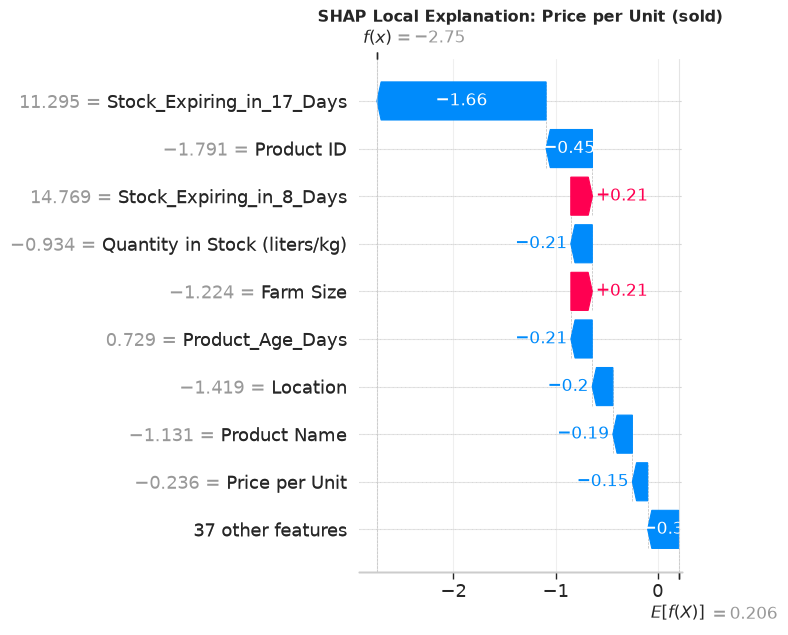


Generating Local Explanation for Action: Reorder Quantity (liters/kg) (Transaction #0)


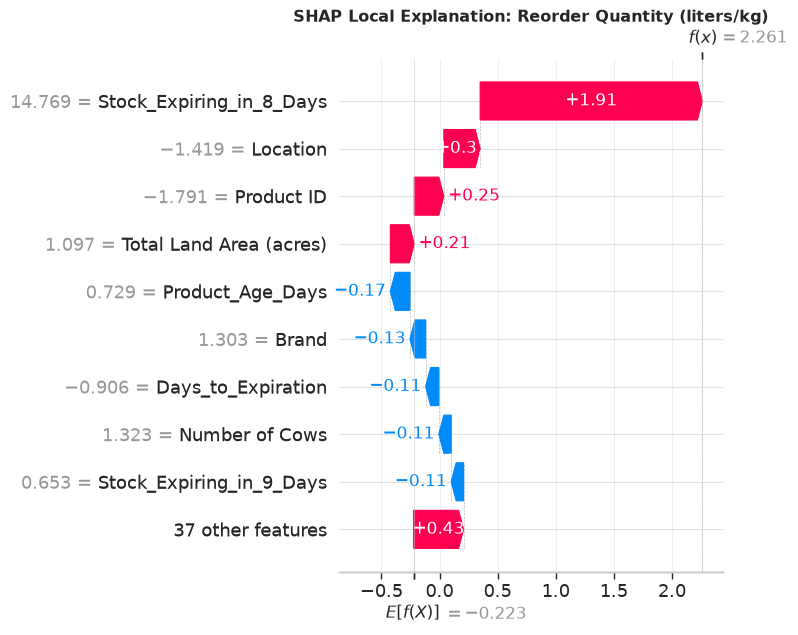

In [30]:
INSTANCE_IDX = 0

action_names = ["Price per Unit (sold)", "Reorder Quantity (liters/kg)"]

for action_idx, action_name in enumerate(action_names):
    print(
        f"\nGenerating Local Explanation for Action: {action_name} (Transaction #{INSTANCE_IDX})"
    )

    with torch.no_grad():
        background_outputs = action_model(background_tensor)
        base_value = background_outputs[:, action_idx].mean().item()

    instance_shap_values = shap_values[action_idx][INSTANCE_IDX]
    instance_feature_values = S_matrix[INSTANCE_IDX]

    explanation = shap.Explanation(
        values=instance_shap_values,
        base_values=base_value,
        data=instance_feature_values,
        feature_names=state_cols,
    )

    plt.figure(figsize=(10, 6))
    plt.title(f"SHAP Local Explanation: {action_name}")
    shap.waterfall_plot(explanation, max_display=10, show=False)
    plt.tight_layout()
    plt.show()

#### Summary Profile



Generating Global Summary for 'Price per Unit (sold)' across test batch...


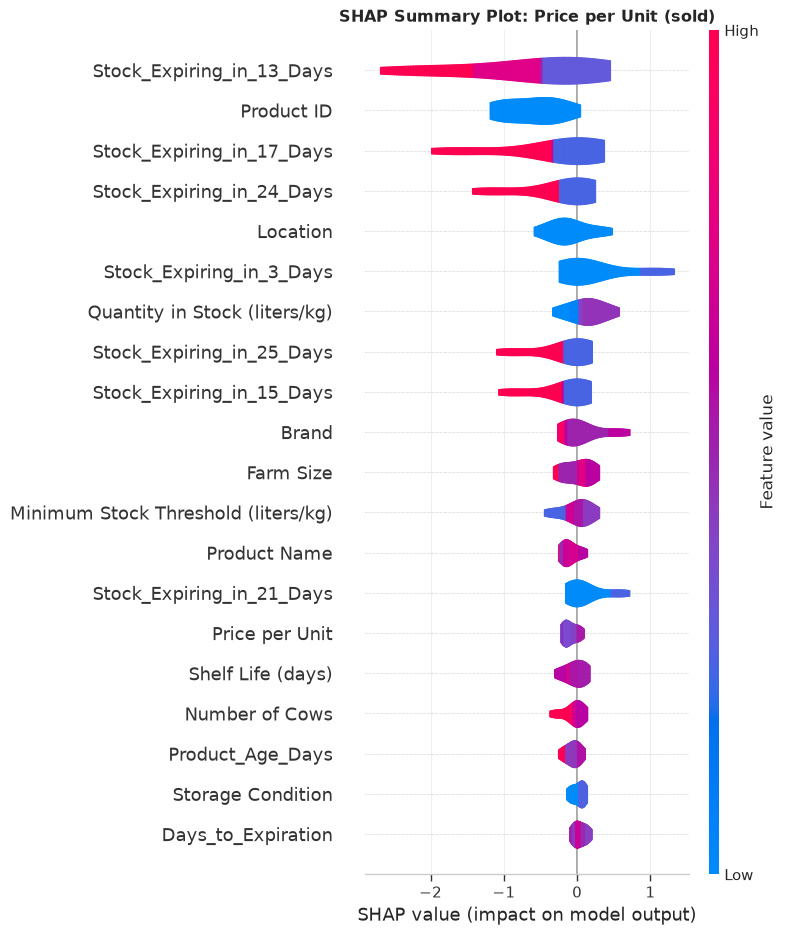

In [31]:
print("\nGenerating Global Summary for 'Price per Unit (sold)' across test batch...")
plt.figure(figsize=(10, 6))
plt.title(f"SHAP Summary Plot: {action_names[0]}")
shap.summary_plot(
    shap_values[0],
    test_tensor.cpu().numpy(),
    feature_names=state_cols,
    show=False,
    plot_type="violin",
)
plt.tight_layout()
plt.show()

### Global Explanations via Symbolic Decision Trees


#### Generate RL Agent Predictions for the Entire Dataset


In [32]:
print("Generating agent predictions to train the surrogate...")
with torch.no_grad():
    S_tensor = torch.tensor(S_matrix, dtype=torch.float32).to(device)
    A_pred_tensor, _, _ = dqn_agent(S_tensor)
    A_pred_scaled = A_pred_tensor.cpu().numpy()

A_pred_real = scaler_A.inverse_transform(A_pred_scaled)
print("Generating agent predictions to train the surrogate successfully...")

Generating agent predictions to train the surrogate...
Generating agent predictions to train the surrogate successfully...


#### Train the Symbolic Surrogate Models


In [33]:
from sklearn.tree import DecisionTreeRegressor

print("Training Surrogate Decision Trees on unscaled features...")
X_raw = rl_df_final[state_cols]

dt_price = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_price.fit(X_raw, A_pred_real[:, 0])

dt_reorder = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_reorder.fit(X_raw, A_pred_real[:, 1])
print("Training Surrogate Decision Trees on unscaled features successfully...")

Training Surrogate Decision Trees on unscaled features...
Training Surrogate Decision Trees on unscaled features successfully...


#### Extract Human-Readable IF-THEN Rules


In [34]:
from sklearn.tree import export_text, plot_tree

print("\n" + "-" * 60)
print("GLOBAL STRATEGY RULES: PRICE PER UNIT (SOLD)")
print("-" * 60)
rules_price = export_text(dt_price, feature_names=list(X_raw.columns))
print(rules_price)

print("\n" + "-" * 60)
print("GLOBAL STRATEGY RULES: REORDER QUANTITY")
print("-" * 60)
rules_reorder = export_text(dt_reorder, feature_names=list(X_raw.columns))
print(rules_reorder)


------------------------------------------------------------
GLOBAL STRATEGY RULES: PRICE PER UNIT (SOLD)
------------------------------------------------------------
|--- Price per Unit <= 65.59
|   |--- Price per Unit <= 47.52
|   |   |--- Product ID <= 10.00
|   |   |   |--- value: [45.24]
|   |   |--- Product ID >  10.00
|   |   |   |--- value: [72.08]
|   |--- Price per Unit >  47.52
|   |   |--- Quantity in Stock (liters/kg) <= 59.45
|   |   |   |--- value: [47.36]
|   |   |--- Quantity in Stock (liters/kg) >  59.45
|   |   |   |--- value: [60.88]
|--- Price per Unit >  65.59
|   |--- Quantity in Stock (liters/kg) <= 57.36
|   |   |--- Price per Unit <= 90.06
|   |   |   |--- value: [56.94]
|   |   |--- Price per Unit >  90.06
|   |   |   |--- value: [71.59]
|   |--- Quantity in Stock (liters/kg) >  57.36
|   |   |--- Price per Unit <= 85.80
|   |   |   |--- value: [76.02]
|   |   |--- Price per Unit >  85.80
|   |   |   |--- value: [93.71]


------------------------------------

#### Evaluate Surrogate Fidelity ($R^2$ Score)


In [35]:
score_price = dt_price.score(X_raw, A_pred_real[:, 0])
score_inv = dt_reorder.score(X_raw, A_pred_real[:, 1])

print("\nSurrogate Fidelity Check (R^2 Score):")
print(f"-> Pricing Strategy Tree Fidelity: {score_price:.4f}")
print(f"-> Reorder Strategy Tree Fidelity: {score_inv:.4f}")

if score_price < 0.70 or score_inv < 0.70:
    print(
        "\n* Note: A lower fidelity score is expected when severely restricting tree depth (max_depth=3)."
    )
    print(
        "  To increase fidelity, increase max_depth, though this will reduce human interpretability."
    )


Surrogate Fidelity Check (R^2 Score):
-> Pricing Strategy Tree Fidelity: 0.3632
-> Reorder Strategy Tree Fidelity: 0.0702

* Note: A lower fidelity score is expected when severely restricting tree depth (max_depth=3).
  To increase fidelity, increase max_depth, though this will reduce human interpretability.


#### Visualizing the Strategy Tree



Generating Decision Tree Visualization for Pricing Strategy...


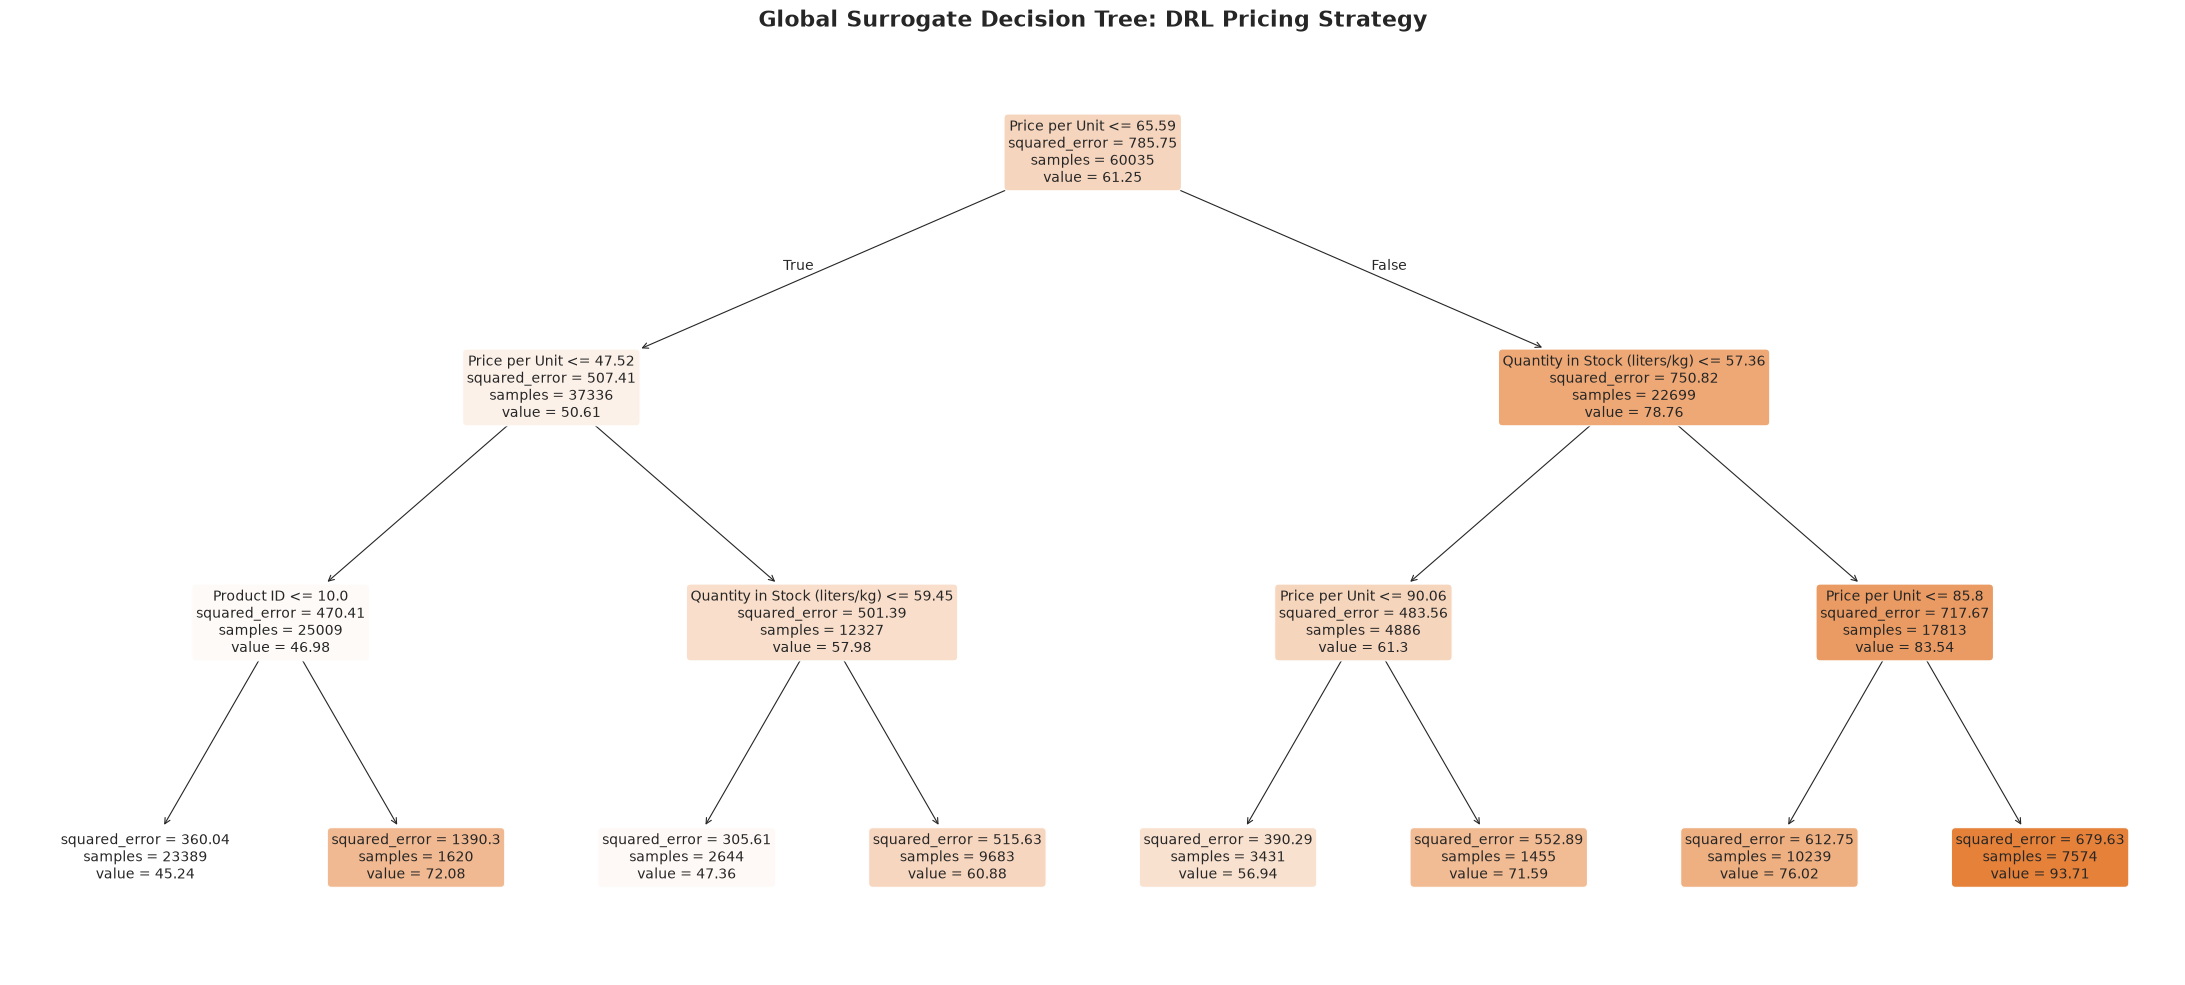

In [36]:
print("\nGenerating Decision Tree Visualization for Pricing Strategy...")
plt.figure(figsize=(22, 10))
plot_tree(
    dt_price,
    feature_names=list(X_raw.columns),
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
)
plt.title("Global Surrogate Decision Tree: DRL Pricing Strategy", fontsize=16)
plt.tight_layout()
plt.show()


Generating Decision Tree Visualization for Reordering Strategy...


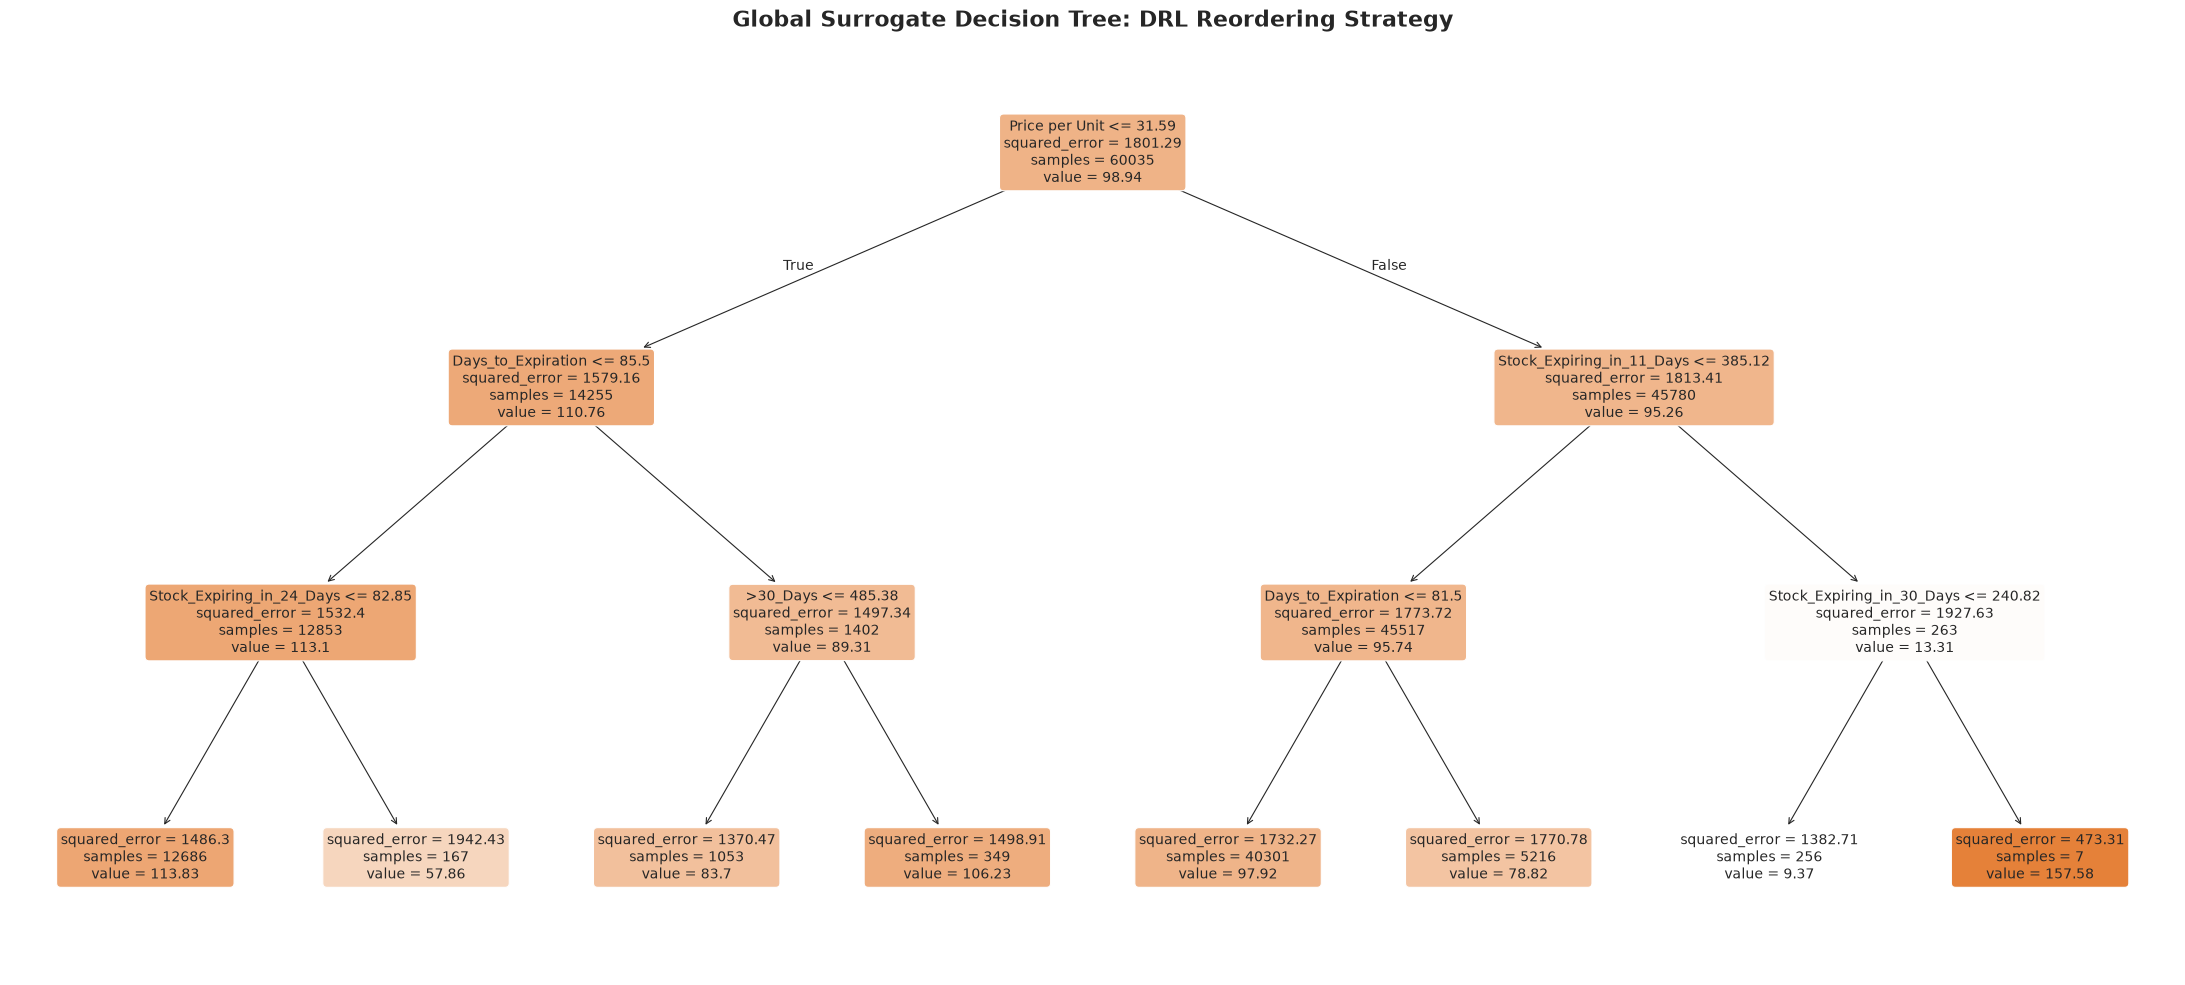

In [37]:
print("\nGenerating Decision Tree Visualization for Reordering Strategy...")
plt.figure(figsize=(22, 10))
plot_tree(
    dt_reorder,
    feature_names=list(X_raw.columns),
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
)
plt.title("Global Surrogate Decision Tree: DRL Reordering Strategy", fontsize=16)
plt.tight_layout()
plt.show()

### Reward Decomposition (Post-Hoc Financial Surrogate)


#### Prepare Data for the Reward Surrogate


In [38]:
print("Preparing State-Action paired data...")
X_hist = np.hstack([S_matrix, A_matrix])
Y_hist = rl_df_final[
    ["Gross_Profit", "Waste_Penalty", "Holding_Cost", "Stockout_Penalty"]
].values

X_agent_policy = np.hstack([S_matrix, A_pred_scaled])
feature_names_extended = state_cols + action_cols
print("Preparing State-Action paired data successfully...")

Preparing State-Action paired data...
Preparing State-Action paired data successfully...


#### Train the Multi-Output Reward Surrogate


In [39]:
from sklearn.ensemble import RandomForestRegressor

print("Training Multi-Output Random Forest Surrogate for Reward Decomposition...")
reward_surrogate = RandomForestRegressor(
    n_estimators=50, max_depth=10, random_state=42, n_jobs=-1
)
reward_surrogate.fit(X_hist, Y_hist)
print(
    "Training Multi-Output Random Forest Surrogate for Reward Decomposition successfully..."
)

Training Multi-Output Random Forest Surrogate for Reward Decomposition...
Training Multi-Output Random Forest Surrogate for Reward Decomposition successfully...


#### Predict Sub-Rewards for the Agent's Policy


In [40]:
print("Decomposing Agent's Expected Rewards...")
Y_agent_expected = reward_surrogate.predict(X_agent_policy)
print("Decomposing Agent's Expected Rewards successfully...")

Decomposing Agent's Expected Rewards...
Decomposing Agent's Expected Rewards successfully...


#### Visualizing Reward Decomposition for a Specific Transaction


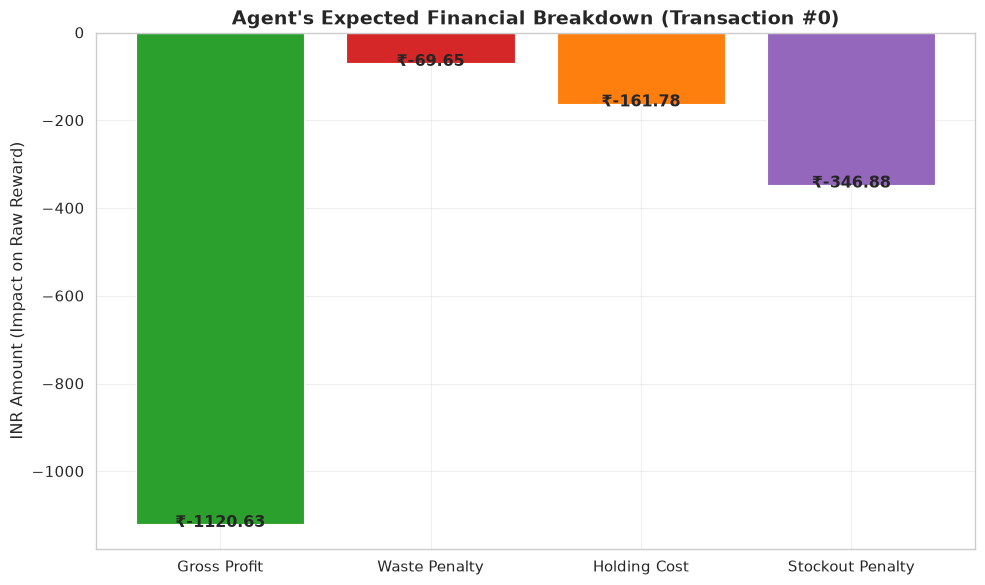

In [41]:
sub_rewards = Y_agent_expected[INSTANCE_IDX]

labels = ["Gross Profit", "Waste Penalty", "Holding Cost", "Stockout Penalty"]
values = [sub_rewards[0], -sub_rewards[1], -sub_rewards[2], -sub_rewards[3]]
colors = ["#2ca02c", "#d62728", "#ff7f0e", "#9467bd"]

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=colors)
plt.axhline(0, color="black", linewidth=1.2)
plt.title(
    f"Agent's Expected Financial Breakdown (Transaction #{INSTANCE_IDX})", fontsize=14
)
plt.ylabel("INR Amount (Impact on Raw Reward)")

for bar, v in zip(bars, values):
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + (5 if v > 0 else -15),
        f"₹{v:.2f}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

#### SHAP Analysis: Isolating a Specific Objective (Waste Penalty)



Applying SHAP to explain how the Agent controls the 'Waste Penalty' Objective...


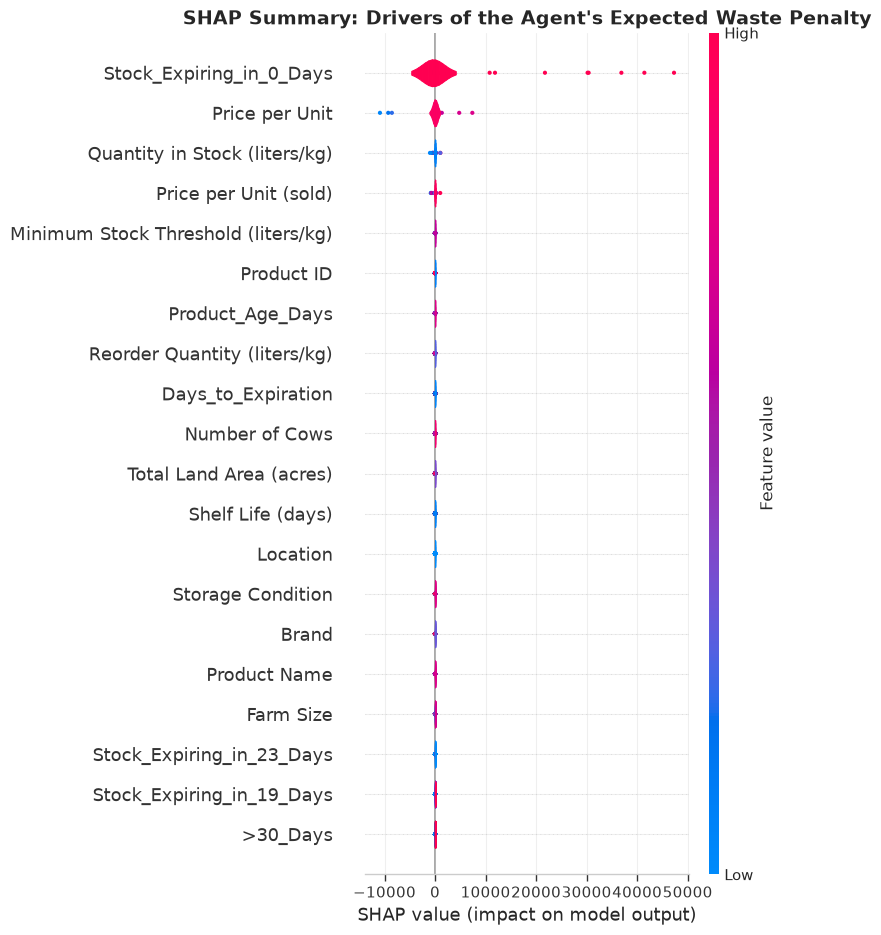

In [42]:
print(
    "\nApplying SHAP to explain how the Agent controls the 'Waste Penalty' Objective..."
)

tree_explainer = shap.TreeExplainer(reward_surrogate)

X_explain = X_agent_policy[:200]
shap_values_rf = tree_explainer.shap_values(X_explain)

if isinstance(shap_values_rf, list):
    waste_shap_values = shap_values_rf[1]
else:
    waste_shap_values = shap_values_rf[:, :, 1]

plt.figure(figsize=(12, 6))
plt.title("SHAP Summary: Drivers of the Agent's Expected Waste Penalty", fontsize=14)
shap.summary_plot(
    waste_shap_values,
    X_explain,
    feature_names=feature_names_extended,
    show=False,
    plot_type="violin",
)
plt.tight_layout()
plt.show()

### Post-Hoc XAI Evaluation & Validation


#### Global Fidelity vs. Interpretability Trade-Off


Evaluating Global Surrogate Fidelity across explanation complexities...


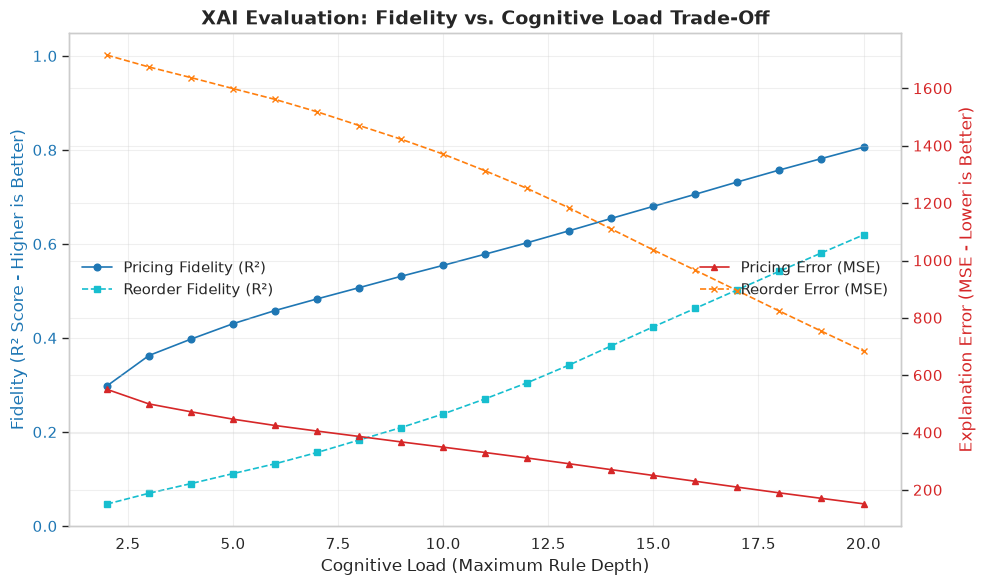

In [43]:
from sklearn.metrics import mean_squared_error, r2_score

print("Evaluating Global Surrogate Fidelity across explanation complexities...")

depths = range(2, 21)
fidelity_r2_price = []
fidelity_r2_reorder = []
mse_price = []
mse_reorder = []

X_raw = rl_df_final[state_cols]
y_price = A_pred_real[:, 0]
y_reorder = A_pred_real[:, 1]

for d in depths:
    dt_p = DecisionTreeRegressor(max_depth=d, random_state=42)
    dt_p.fit(X_raw, y_price)
    preds_p = dt_p.predict(X_raw)
    fidelity_r2_price.append(r2_score(y_price, preds_p))
    mse_price.append(mean_squared_error(y_price, preds_p))

    dt_r = DecisionTreeRegressor(max_depth=d, random_state=42)
    dt_r.fit(X_raw, y_reorder)
    preds_r = dt_r.predict(X_raw)
    fidelity_r2_reorder.append(r2_score(y_reorder, preds_r))
    mse_reorder.append(mean_squared_error(y_reorder, preds_r))

fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = "tab:blue"
color2 = "tab:cyan"
ax1.set_xlabel("Cognitive Load (Maximum Rule Depth)", fontsize=12)
ax1.set_ylabel("Fidelity (R² Score - Higher is Better)", color=color1, fontsize=12)
ax1.plot(
    depths, fidelity_r2_price, marker="o", label="Pricing Fidelity (R²)", color=color1
)
ax1.plot(
    depths,
    fidelity_r2_reorder,
    marker="s",
    linestyle="--",
    label="Reorder Fidelity (R²)",
    color=color2,
)
ax1.tick_params(axis="y", labelcolor=color1)
ax1.set_ylim((0, 1.05))
ax1.legend(loc="center left")
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
color3 = "tab:red"
color4 = "tab:orange"
ax2.set_ylabel("Explanation Error (MSE - Lower is Better)", color=color3, fontsize=12)
ax2.plot(depths, mse_price, marker="^", label="Pricing Error (MSE)", color=color3)
ax2.plot(
    depths,
    mse_reorder,
    marker="x",
    linestyle="--",
    label="Reorder Error (MSE)",
    color=color4,
)
ax2.tick_params(axis="y", labelcolor=color3)
ax2.legend(loc="center right")

plt.title("XAI Evaluation: Fidelity vs. Cognitive Load Trade-Off", fontsize=14)
fig.tight_layout()
plt.savefig(
    "./plots/Continuous_DQN_Fidelity_vs_Cognitive_Load.pdf",
    format="pdf",
    dpi=1200,
    bbox_inches="tight",
)
plt.show()

#### Local Fidelity (SHAP Completeness Axiom)


In [44]:
print("\nEvaluating Local Explanation Fidelity (SHAP Completeness Axiom)...")

local_fidelity_passed = True
action_names = ["Price per Unit (sold)", "Reorder Quantity (liters/kg)"]

for action_idx, action_name in enumerate(action_names):
    print(f"\nVerifying Completeness for Action: {action_name}")

    with torch.no_grad():
        background_outputs = action_model(background_tensor)
        expected_val = background_outputs[:, action_idx].mean().item()
        actual_preds = action_model(test_tensor)[:, action_idx].cpu().numpy()

    shap_sums = shap_values[action_idx].sum(axis=1)

    for i in range(len(test_indices)):
        explanation_pred = shap_sums[i] + expected_val
        actual_pred = actual_preds[i]
        diff = abs(explanation_pred - actual_pred)

        print(
            f" Instance #{i} | Actual DRL Output: {actual_pred:.4f} | SHAP Explained Output: {explanation_pred:.4f} | Math Diff: {diff:.6f}"
        )

        if diff > 1e-4:
            local_fidelity_passed = False

if local_fidelity_passed:
    print(
        "\n[SUCCESS] Local Fidelity Check Passed: SHAP values strictly reconstruct the DRL agent's local decisions."
    )
else:
    print(
        "\n[WARNING] Local Fidelity Check Failed: SHAP explanations do not sum to the DRL output. The approximation is leaking information."
    )


Evaluating Local Explanation Fidelity (SHAP Completeness Axiom)...

Verifying Completeness for Action: Price per Unit (sold)
 Instance #0 | Actual DRL Output: -2.7676 | SHAP Explained Output: -2.7497 | Math Diff: 0.017880
 Instance #1 | Actual DRL Output: -1.9074 | SHAP Explained Output: -2.1593 | Math Diff: 0.251886
 Instance #2 | Actual DRL Output: -1.2226 | SHAP Explained Output: -1.2777 | Math Diff: 0.055144
 Instance #3 | Actual DRL Output: -2.1726 | SHAP Explained Output: -2.0354 | Math Diff: 0.137227
 Instance #4 | Actual DRL Output: -1.1272 | SHAP Explained Output: -1.5186 | Math Diff: 0.391395

Verifying Completeness for Action: Reorder Quantity (liters/kg)
 Instance #0 | Actual DRL Output: 2.3989 | SHAP Explained Output: 2.2613 | Math Diff: 0.137619
 Instance #1 | Actual DRL Output: -1.2143 | SHAP Explained Output: -1.1341 | Math Diff: 0.080120
 Instance #2 | Actual DRL Output: -1.2835 | SHAP Explained Output: -1.5004 | Math Diff: 0.216888
 Instance #3 | Actual DRL Output: -

### Selectivity & Perturbation (PI / Masking)


#### Identify Top and Bottom Features from SHAP


In [45]:
mean_abs_shap = np.abs(shap_values[0]).mean(axis=0)
sorted_feature_indices = np.argsort(mean_abs_shap)[::-1]

top_3_indices = sorted_feature_indices[:3]
top_3_features = [state_cols[i] for i in top_3_indices]
print(f"Top 3 Features identified by SHAP: \n{top_3_features}\n")

bottom_3_indices = sorted_feature_indices[-3:]
bottom_3_features = [state_cols[i] for i in bottom_3_indices]

Top 3 Features identified by SHAP: 
['Stock_Expiring_in_13_Days', 'Product ID', 'Stock_Expiring_in_17_Days']



#### Collinearity Check


In [46]:
print("Executing Collinearity Check...")

for feat in top_3_features:
    corrs = []
    for f1, f2, val in collinear_pairs:
        if feat == f1:
            corrs.append(f2)
        elif feat == f2:
            corrs.append(f1)

    if corrs:
        print(
            f" [!] WARNING: '{feat}' is highly correlated with {corrs}. Masking it might trigger the agent to use the correlated proxy."
        )
    else:
        print(f" [OK] '{feat}' is independent. No collinearity detected.")

Executing Collinearity Check...
 [OK] 'Stock_Expiring_in_13_Days' is independent. No collinearity detected.
 [OK] 'Product ID' is independent. No collinearity detected.
 [OK] 'Stock_Expiring_in_17_Days' is independent. No collinearity detected.


#### Permutation Importance / Masking Evaluation


In [47]:
print("\nEvaluating Agent Performance Drop (Perturbation Importance)...")


def evaluate_policy_reward(state_tensor):
    with torch.no_grad():
        pred_actions, _, _ = dqn_agent(state_tensor)

    X_eval = np.hstack([state_tensor.cpu().numpy(), pred_actions.cpu().numpy()])
    sub_rewards = reward_surrogate.predict(X_eval)

    raw_rewards = (
        sub_rewards[:, 0] - sub_rewards[:, 1] - sub_rewards[:, 2] - sub_rewards[:, 3]
    )
    return raw_rewards.mean()


baseline_reward = evaluate_policy_reward(test_tensor)
print(f"-> Baseline Expected Reward (Unperturbed): ₹{baseline_reward:.2f}")

perturbed_states_top = test_tensor.clone()
for idx in top_3_indices:
    perturbed_states_top[:, idx] = 0.0

degraded_reward_top = evaluate_policy_reward(perturbed_states_top)
drop_pct_top = ((baseline_reward - degraded_reward_top) / abs(baseline_reward)) * 100
print(f"-> Expected Reward (Top 3 Features Masked): ₹{degraded_reward_top:.2f}")
print(f"-> Performance Impact: {drop_pct_top:.2f}% drop")

print(f"\nSanity Check: Masking Bottom 3 Features \n{bottom_3_features}...")
perturbed_states_bottom = test_tensor.clone()
for idx in bottom_3_indices:
    perturbed_states_bottom[:, idx] = 0.0

degraded_reward_bottom = evaluate_policy_reward(perturbed_states_bottom)
drop_pct_bottom = (
    (baseline_reward - degraded_reward_bottom) / abs(baseline_reward)
) * 100
print(f"-> Expected Reward (Bottom 3 Features Masked): ₹{degraded_reward_bottom:.2f}")
print(f"-> Performance Impact: {drop_pct_bottom:.2f}% drop")


Evaluating Agent Performance Drop (Perturbation Importance)...
-> Baseline Expected Reward (Unperturbed): ₹-2731.55
-> Expected Reward (Top 3 Features Masked): ₹-2355.36
-> Performance Impact: -13.77% drop

Sanity Check: Masking Bottom 3 Features 
['Stock_Expiring_in_16_Days', 'Stock_Expiring_in_14_Days', 'Stock_Expiring_in_23_Days']...
-> Expected Reward (Bottom 3 Features Masked): ₹-2731.55
-> Performance Impact: 0.00% drop


#### Visualization of Performance Degradation


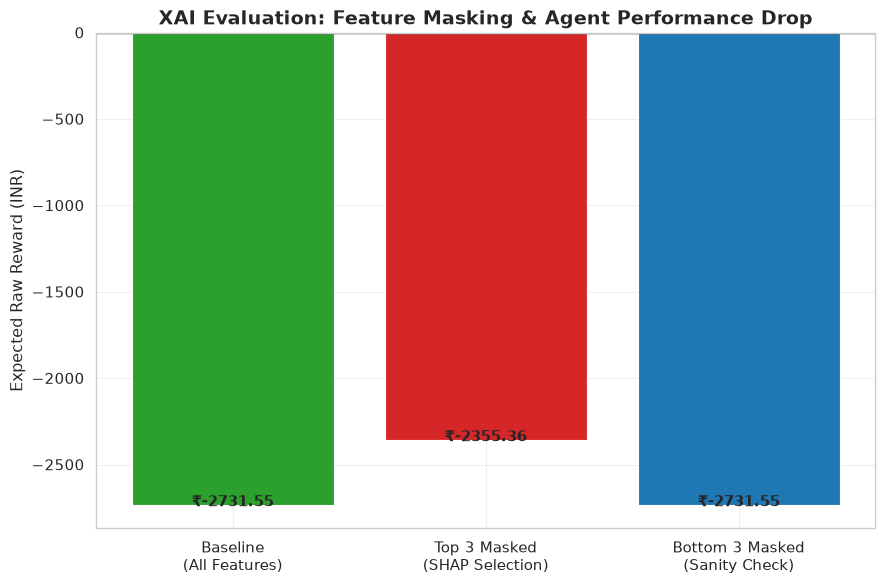

In [48]:
labels = [
    "Baseline\n(All Features)",
    "Top 3 Masked\n(SHAP Selection)",
    "Bottom 3 Masked\n(Sanity Check)",
]
values = [baseline_reward, degraded_reward_top, degraded_reward_bottom]
colors = ["#2ca02c", "#d62728", "#1f77b4"]

plt.figure(figsize=(9, 6))
bars = plt.bar(labels, values, color=colors)
plt.title("XAI Evaluation: Feature Masking & Agent Performance Drop", fontsize=14)
plt.ylabel("Expected Raw Reward (INR)")
plt.axhline(0, color="black", linewidth=1)

for bar, v in zip(bars, values):
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + (10 if v > 0 else -30),
        f"₹{v:.2f}",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=11,
    )

plt.tight_layout()
plt.show()

### Stability & Robustness Profiling (Lipschitz Continuity)


#### Generate Local Perturbations (Noise Injection)


In [49]:
print("Generating 100 near-identical state transitions...")
NUM_SAMPLES = 100
ACTION_IDX = 0

base_state = S_matrix[INSTANCE_IDX]

np.random.seed(42)
noise = np.random.normal(loc=0.0, scale=0.01, size=(NUM_SAMPLES, STATE_DIM))
perturbed_states = base_state + noise

perturbed_states[0] = base_state
perturbed_tensor = torch.tensor(perturbed_states, dtype=torch.float32).to(device)

Generating 100 near-identical state transitions...


#### Extract SHAP Explanations for Perturbed States


In [50]:
print("Calculating SHAP values for perturbed states...")
shap_values_perturbed = explainer.shap_values(perturbed_tensor)

if isinstance(shap_values_perturbed, list):
    shap_action_perturbed = shap_values_perturbed[ACTION_IDX]
else:
    shap_action_perturbed = shap_values_perturbed[:, :, ACTION_IDX]

base_shap = shap_action_perturbed[0]

Calculating SHAP values for perturbed states...


#### Calculate Lipschitz Continuity and Variance


In [51]:
from scipy.spatial.distance import cdist

print("Calculating Lipschitz constants and feature-wise variance...")

dx = cdist([base_state], perturbed_states, metric="euclidean")[0] + 1e-9
de = cdist([base_shap], shap_action_perturbed, metric="euclidean")[0]

lipschitz_ratios = de / dx
local_lipschitz_constant = np.max(lipschitz_ratios[1:])

shap_variances = np.var(shap_action_perturbed, axis=0)

print("\nStability Metrics:")
print("-" * 60)
print(f"-> Local Lipschitz Constant (L): {local_lipschitz_constant:.4f}")
if local_lipschitz_constant < 5.0:
    print(
        "   [OK] Low Lipschitz constant. The explanations are highly stable and trustworthy."
    )
else:
    print(
        "   [WARNING] High Lipschitz constant. The explanations are fragile to noise."
    )

Calculating Lipschitz constants and feature-wise variance...

Stability Metrics:
------------------------------------------------------------
-> Local Lipschitz Constant (L): 15.1005
   [WARNING] High Lipschitz constant. The explanations are fragile to noise.


#### Visualization of XAI Robustness



Generating Robustness Profile Visualizations...


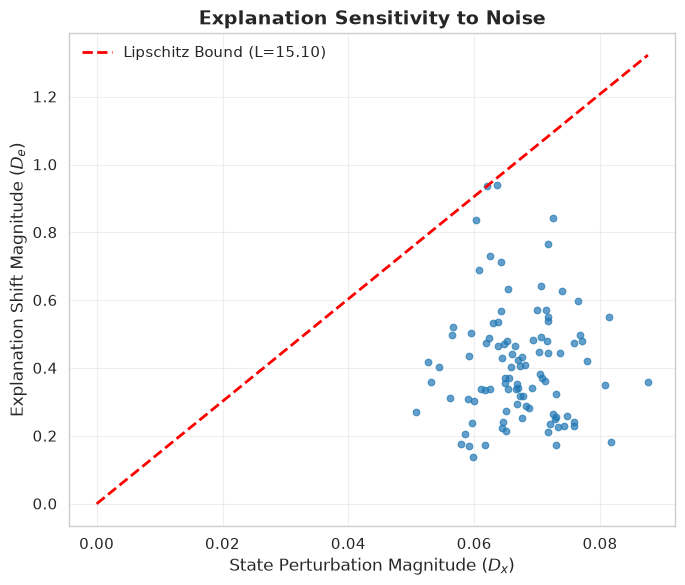

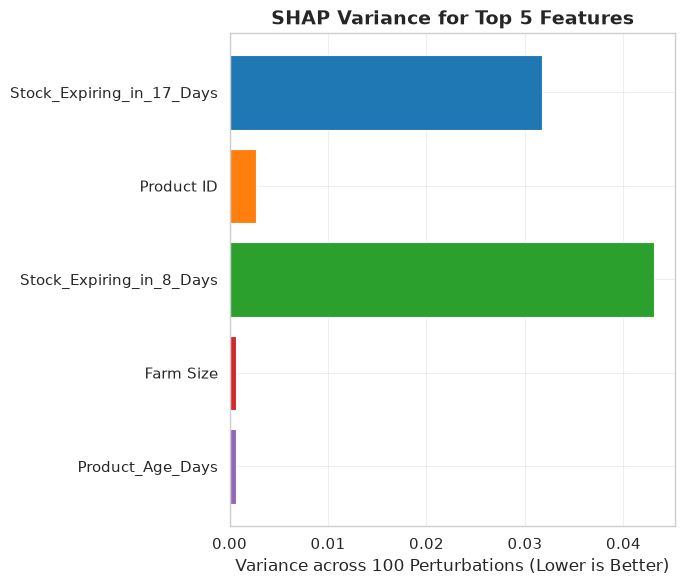

In [52]:
print("\nGenerating Robustness Profile Visualizations...")

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111)

ax.scatter(dx[1:], de[1:], alpha=0.7, color="#1f77b4")
ax.set_title("Explanation Sensitivity to Noise", fontsize=14)
ax.set_xlabel(r"State Perturbation Magnitude ($D_x$)", fontsize=12)
ax.set_ylabel(r"Explanation Shift Magnitude ($D_e$)", fontsize=12)
ax.grid(alpha=0.3)

x_vals = np.linspace(0, np.max(dx), 100)
y_vals = local_lipschitz_constant * x_vals

ax.plot(
    x_vals,
    y_vals,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Lipschitz Bound (L={local_lipschitz_constant:.2f})",
)
ax.legend()

plt.tight_layout()
plt.savefig(
    "./plots/Continuous_DQN_Explanation_Sensitivity_to_Noise.pdf",
    format="pdf",
    dpi=1200,
    bbox_inches="tight",
)
plt.show()

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111)

top_5_indices = np.argsort(np.abs(base_shap))[::-1][:5]
top_5_features = [state_cols[i] for i in top_5_indices]
top_5_variances = shap_variances[top_5_indices]

ax.barh(
    top_5_features[::-1],
    top_5_variances[::-1],
    color=["#9467bd", "#d62728", "#2ca02c", "#ff7f0e", "#1f77b4"],
)
ax.set_title("SHAP Variance for Top 5 Features", fontsize=14)
ax.set_xlabel("Variance across 100 Perturbations (Lower is Better)", fontsize=12)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(
    "./plots/Continuous_DQN_SHAP_Variance_Top5_Features.pdf",
    format="pdf",
    dpi=1200,
    bbox_inches="tight",
)
plt.show()

## Architectural Metric Summary


In [53]:
import pandas as pd

Continuous_DQN_data = {
    "Average Reward": f"{A_pred_scaled.mean():.4f}",
    "Policy Loss": f"{training_history['policy_loss'][-1]:.4f}",
    "Value Loss": f"{training_history['value_loss'][-1]:.4f}",
    "MAE": f"{p_mae:.4f}",
    "RMSE": f"{p_rmse:.4f}",
    "R²": f"{p_r2:.4f}",
    "Pricing Accuracy": f"{p_acc:.2f}%",
    "Reordering Accuracy": f"{r_acc:.2f}%",
    "Overall DRL Accuracy": f"{overall_drl_acc:.2f}%",
    "Training Time": f"{elapsed_time:.2f} sec",
    "Pricing Strategy Tree Fidelity (Depth=3)": f"{score_price * 100:.2f}%",
    "Reorder Strategy Tree Fidelity (Depth=3)": f"{score_inv * 100:.2f}%",
    "Baseline Expected Reward (Unperturbed)": f"₹{baseline_reward:.2f}",
    "Expected Reward (Top 3 Features Masked)": f"₹{degraded_reward_top:.2f}",
    "Expected Reward (Bottom 3 Features Masked):": f"₹{degraded_reward_bottom:.2f}",
    "Performance Impact (Top 3 Features Masked)": f"{drop_pct_top:.2f}%",
    "Performance Impact (Bottom 3 Features Masked)": f"{drop_pct_bottom:.2f}%",
    "Lipschitz Constant": local_lipschitz_constant,
}

Continuous_DQN_df = pd.DataFrame([Continuous_DQN_data], index=["Continuous_DQN"]).T
Continuous_DQN_df.to_csv("./results/Continuous_DQN_df.csv", index=True)
Continuous_DQN_df

,Continuous_DQN
Average Reward,0.0344
Policy Loss,0.0136
Value Loss,0.4349
MAE,20.8031
RMSE,27.3074
R²,-0.0584
Pricing Accuracy,72.50%
Reordering Accuracy,62.31%
Overall DRL Accuracy,67.41%
Training Time,174.35 sec
